In [40]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, precision_recall_curve, classification_report
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

# Load data

In [4]:
FILM_METADATA_PATH = 'data/merged_film_data.csv'
FILM_FEATURES_PATH = 'output_final/film_network_features.csv'

In [5]:
filmMetadata = pd.read_csv(FILM_METADATA_PATH)
filmFeatures = pd.read_csv(FILM_FEATURES_PATH)

In [6]:
print(f"film metadata: {len(filmMetadata):,} rows")
print(f"film network features: {len(filmFeatures):,} films")
print(f"\nfilm features columns: {list(filmFeatures.columns)}")

film metadata: 105,266 rows
film network features: 7,145 films

film features columns: ['film_id', 'filmrank', 'premiere_festival', 'premiere_year', 'premiere_festival_filmrank', 'played_strategic', 'num_strategic', 'max_strategic_filmrank', 'avg_strategic_filmrank', 'played_top5_festival', 'played_top10_festival', 'num_top5_festivals', 'num_top10_festivals']


## create target var

In [7]:
# the film metadata may have multiple rows per film (one per award) 
aggDict = {
    # award info 
    'awards.nom.win': lambda x: list(x.dropna().unique()),
    'award.institution': lambda x: len([i for i in x.dropna() if i != '']),
    
    # film attributes 
    'imdb.id': 'first',
    'title.mixed': 'first',
    'prod.year': 'first',
    'length.min': 'first',
    'prod.country.1.en': 'first',
    'competition': 'max',
    'sample.year.first': 'first',
}

In [9]:
# add region columns 
for col in ['regions.eu', 'regions.na', 'regions.asia', 'regions.la', 
            'regions.mena', 'regions.africa', 'regions.ocean']:
    if col in filmMetadata.columns:
        aggDict[col] = 'first'

In [10]:
# add genre columns 
for col in ['doc', 'fict', 'animt', 'exp']:
    if col in filmMetadata.columns:
        aggDict[col] = 'first'

In [11]:
# aggregate to film level
filmLevel = filmMetadata.groupby('unique.id').agg(aggDict).reset_index()

In [12]:
# create primary target: did the film win at least one award?
# per modeling plan: "binary indicator: did the film win at least one award at any festival"
filmLevel['has_award'] = filmLevel['awards.nom.win'].apply(
    lambda x: 1 if len([i for i in x if i and str(i).strip()]) > 0 else 0
)

In [14]:
# also create win-specific target (more stringent, did they actually win)
filmLevel['has_win'] = filmLevel['awards.nom.win'].apply(
    lambda x: 1 if any('win' in str(i).lower() or 'won' in str(i).lower() for i in x) else 0
)

In [15]:
# count of awards 
filmLevel['award_count'] = filmLevel['award.institution']

# basic features

In [17]:
# filmrank features, map to film
modelingDf = filmLevel.merge(
    filmFeatures,
    left_on='unique.id',
    right_on='film_id',
    how='inner'
)

In [18]:
# baseline, pre festival features
# genre features , one hot enc
if 'doc' in modelingDf.columns:
    modelingDf['is_doc'] = (modelingDf['doc'] == 1).astype(int)
if 'fict' in modelingDf.columns:
    modelingDf['is_fict'] = (modelingDf['fict'] == 1).astype(int)
if 'animt' in modelingDf.columns:
    modelingDf['is_animt'] = (modelingDf['animt'] == 1).astype(int)
if 'exp' in modelingDf.columns:
    modelingDf['is_exp'] = (modelingDf['exp'] == 1).astype(int)

In [23]:
if 'regions.eu' in modelingDf.columns and 'regions.na' in modelingDf.columns:
    modelingDf['is_western'] = ((modelingDf['regions.eu'] == 1) | 
                                 (modelingDf['regions.na'] == 1)).astype(int)
    modelingDf['is_european'] = (modelingDf['regions.eu'] == 1).astype(int)
    modelingDf['is_north_american'] = (modelingDf['regions.na'] == 1).astype(int)

if 'regions.asia' in modelingDf.columns:
    modelingDf['is_asian'] = (modelingDf['regions.asia'] == 1).astype(int)

# length feature (from modeling plan: "minutes; consider binning")
if 'length.min' in modelingDf.columns:
    modelingDf['length_min'] = modelingDf['length.min'].fillna(modelingDf['length.min'].median())
    # create length category bins as suggested
    modelingDf['is_short'] = (modelingDf['length_min'] < 40).astype(int)
    modelingDf['is_feature'] = (modelingDf['length_min'] >= 40).astype(int)

baselineFeatures = ['is_doc', 'is_fict', 'is_western', 'is_european', 'length_min', 'is_short']

# list filmrank features
filmrankFeatures = [
    'filmrank',
    'premiere_festival_filmrank', 
    'played_strategic',
    'num_strategic',
    'max_strategic_filmrank',
    'avg_strategic_filmrank',
    'played_top5_festival',
    'played_top10_festival',
    'num_top5_festivals',
    'num_top10_festivals',
]


# train test split

In [25]:
TARGET = 'has_award'

# all features for the full model
allFeatures = baselineFeatures + filmrankFeatures
allFeatures = list(set(allFeatures))  # remove any duplicates
print(f"baseline features: {len(baselineFeatures)}")
print(f"filmrank features: {len(filmrankFeatures)}")
print(f"total features: {len(allFeatures)}")

# create feature matrices
X_baseline = modelingDf[baselineFeatures].copy()
X_full = modelingDf[allFeatures].copy()
y = modelingDf[TARGET].copy()

# handle missing values (impute with median as reasonable default)
for col in X_baseline.columns:
    if X_baseline[col].isna().any():
        X_baseline[col] = X_baseline[col].fillna(X_baseline[col].median())

for col in X_full.columns:
    if X_full[col].isna().any():
        X_full[col] = X_full[col].fillna(X_full[col].median())

# stratified split, on target and region to test West v Intl effect
# using 80/20 split
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42, stratify=y
)

X_full_train, X_full_test, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\ntrain set: {len(X_base_train):,} films")
print(f"test set: {len(X_base_test):,} films")
print(f"train target distribution: {y_train.value_counts().to_dict()}")
print(f"test target distribution: {y_test.value_counts().to_dict()}")

# check class imbalance 
pos_rate = y_train.mean()
print(f"\nclass imbalance: {pos_rate:.1%} positive class")

baseline features: 6
filmrank features: 10
total features: 16

train set: 4,972 films
test set: 1,244 films
train target distribution: {1: 3912, 0: 1060}
test target distribution: {1: 979, 0: 265}

class imbalance: 78.7% positive class


# majority class baseline

In [26]:
majorityModel = DummyClassifier(strategy='most_frequent', random_state=42)
majorityModel.fit(X_base_train, y_train)

y_pred_maj = majorityModel.predict(X_base_test)

acc_maj = accuracy_score(y_test, y_pred_maj)
print(f"\nalways predicts: {majorityModel.classes_[np.argmax(majorityModel.class_prior_)]}")
print(f"test accuracy: {acc_maj:.4f}")




always predicts: 1
test accuracy: 0.7870


# Logistic regression baseline

In [30]:
# scale features for logistic regression
scaler_lr = StandardScaler()
X_base_train_scaled = scaler_lr.fit_transform(X_base_train)
X_base_test_scaled = scaler_lr.transform(X_base_test)

# train logistic regression with L2 regularization 
lrModel = LogisticRegression(
    penalty='l2',
    C=1.0,
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'  # handle class imbalance
)
lrModel.fit(X_base_train_scaled, y_train)

# predictions
y_pred_lr = lrModel.predict(X_base_test_scaled)
y_prob_lr = lrModel.predict_proba(X_base_test_scaled)[:, 1]

# metrics 
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)  # primary metric per plan

print(f"\ntest metrics:")
print(f"accuracy:  {acc_lr:.4f}")
print(f"precision: {prec_lr:.4f}")
print(f"recall:    {rec_lr:.4f}")
print(f"f1 score:  {f1_lr:.4f}")
print(f"roc-auc:   {roc_auc_lr:.4f}")
print(f"pr-auc:    {pr_auc_lr:.4f})")


test metrics:
accuracy:  0.6133
precision: 0.8866
recall:    0.5832
f1 score:  0.7036
roc-auc:   0.7118
pr-auc:    0.8926)


# plain xgboost with baseline features

In [39]:
# xgboost model with baseline features only
xgbBaseModel = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
)

# cross-validation
print("\n5-fold stratified cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc_base = cross_val_score(xgbBaseModel, X_base_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_pr_base = cross_val_score(xgbBaseModel, X_base_train_scaled, y_train, cv=cv, scoring='average_precision')
print(f"cv roc-auc: {cv_roc_base.mean():.4f} (+/- {cv_roc_base.std()*2:.4f})")
print(f"cv pr-auc:  {cv_pr_base.mean():.4f} (+/- {cv_pr_base.std()*2:.4f})")

# fit on full training set
xgbBaseModel.fit(X_base_train_scaled, y_train)

# predictions
y_pred_xgb_base = xgbBaseModel.predict(X_base_test_scaled)
y_prob_xgb_base = xgbBaseModel.predict_proba(X_base_test_scaled)[:, 1]

# metrics
acc_xgb_base = accuracy_score(y_test, y_pred_xgb_base)
prec_xgb_base = precision_score(y_test, y_pred_xgb_base, zero_division=0)
rec_xgb_base = recall_score(y_test, y_pred_xgb_base, zero_division=0)
f1_xgb_base = f1_score(y_test, y_pred_xgb_base, zero_division=0)
roc_auc_xgb_base = roc_auc_score(y_test, y_prob_xgb_base)
pr_auc_xgb_base = average_precision_score(y_test, y_prob_xgb_base)

print(f"test metrics:")
print(f"accuracy:  {acc_xgb_base:.4f}")
print(f"precision: {prec_xgb_base:.4f}")
print(f"recall:    {rec_xgb_base:.4f}")
print(f"f1 score:  {f1_xgb_base:.4f}")
print(f"roc-auc:   {roc_auc_xgb_base:.4f}")
print(f"pr-auc:    {pr_auc_xgb_base:.4f}")


5-fold stratified cross-validation...
cv roc-auc: 0.7063 (+/- 0.0432)
cv pr-auc:  0.8907 (+/- 0.0155)
test metrics:
accuracy:  0.6190
precision: 0.8697
recall:    0.6067
f1 score:  0.7148
roc-auc:   0.7002
pr-auc:    0.8895


# xgboost with filmrank

In [31]:
# scale features
HAS_XGBOOST=True
scaler_xgb = StandardScaler()
X_full_train_scaled = scaler_xgb.fit_transform(X_full_train)
X_full_test_scaled = scaler_xgb.transform(X_full_test)

# calculate scale_pos_weight for class imbalance 
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\nclass imbalance handling: scale_pos_weight = {scale_pos_weight:.2f}")

# xgboost model 
xgbModel = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr', 
    max_depth=4,          
    learning_rate=0.1,    
    n_estimators=100,     
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
)

# cross-validation 
print("5-fold stratified cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_roc = cross_val_score(xgbModel, X_full_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_pr = cross_val_score(xgbModel, X_full_train_scaled, y_train, cv=cv, scoring='average_precision')
print(f"cv roc-auc: {cv_roc.mean():.4f} (+/- {cv_roc.std()*2:.4f})")
print(f"cv pr-auc:  {cv_pr.mean():.4f} (+/- {cv_pr.std()*2:.4f})")

# fit on full training set
xgbModel.fit(X_full_train_scaled, y_train)

# predictions
y_pred_xgb = xgbModel.predict(X_full_test_scaled)
y_prob_xgb = xgbModel.predict_proba(X_full_test_scaled)[:, 1]

# metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"test metrics:")
print(f"accuracy:  {acc_xgb:.4f}")
print(f"precision: {prec_xgb:.4f}")
print(f"recall:    {rec_xgb:.4f}")
print(f"f1 score:  {f1_xgb:.4f}")
print(f"roc-auc:   {roc_auc_xgb:.4f}")
print(f"pr-auc:    {pr_auc_xgb:.4f}")


class imbalance handling: scale_pos_weight = 0.27
5-fold stratified cross-validation...
cv roc-auc: 0.8204 (+/- 0.0214)
cv pr-auc:  0.9420 (+/- 0.0091)
test metrics:
accuracy:  0.7363
precision: 0.9115
recall:    0.7365
f1 score:  0.8147
roc-auc:   0.8177
pr-auc:    0.9367
feature importance (gain):
  num_top10_festivals: 0.2085 <- FILMRANK
  filmrank: 0.1832 <- FILMRANK
  is_fict: 0.0873
  is_short: 0.0662
  premiere_festival_filmrank: 0.0636 <- FILMRANK
  length_min: 0.0622
  played_top5_festival: 0.0616 <- FILMRANK
  played_top10_festival: 0.0569 <- FILMRANK
  is_doc: 0.0563
  is_western: 0.0550
  num_top5_festivals: 0.0521 <- FILMRANK
  is_european: 0.0470
  avg_strategic_filmrank: 0.0000 <- FILMRANK
  max_strategic_filmrank: 0.0000 <- FILMRANK
  played_strategic: 0.0000 <- FILMRANK
  num_strategic: 0.0000 <- FILMRANK

confusion matrix:
  TN=195, FP=70
  FN=258, TP=721


# model comparison and visualization
- we should care about pr-auc, because of binary class imbalance

  logistic cv complete


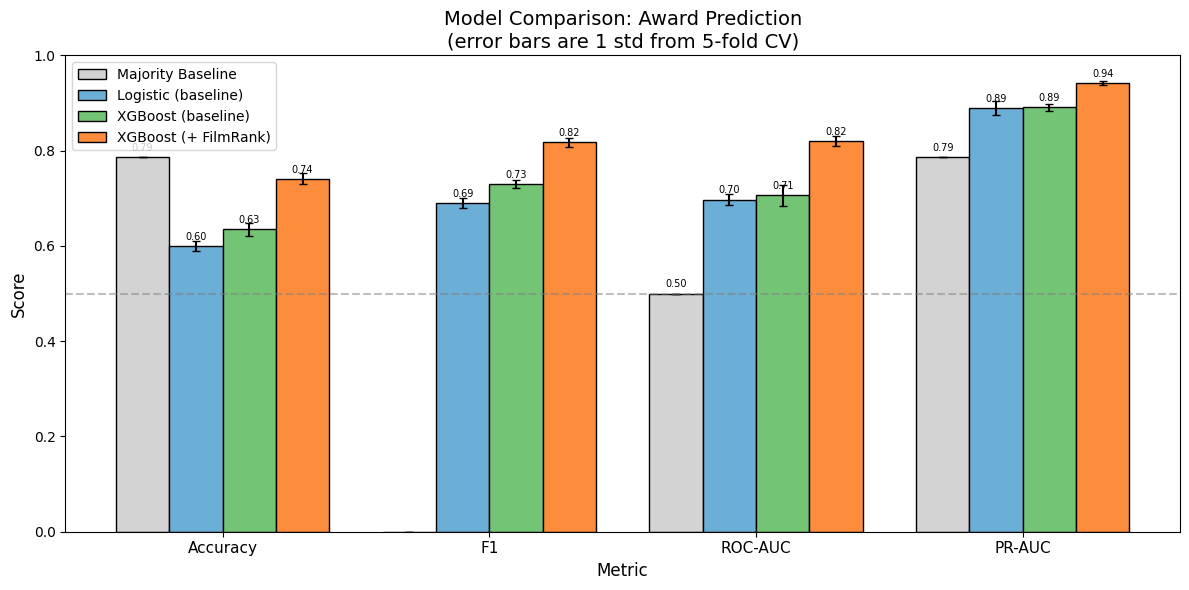


visualization saved to: model_comparison.png


In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# logistic regression cv scores (for accurate error bars)
lr_cv_model = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000, class_weight='balanced')
lr_cv_acc = cross_val_score(lr_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='accuracy')
lr_cv_f1 = cross_val_score(lr_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='f1')
lr_cv_roc = cross_val_score(lr_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='roc_auc')
lr_cv_pr = cross_val_score(lr_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='average_precision')
print(f"  logistic cv complete")

# xgboost baseline cv scores (if available)

xgb_base_cv_model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr', max_depth=4,
    learning_rate=0.1, n_estimators=100, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    random_state=42, use_label_encoder=False
)
xgb_base_cv_acc = cross_val_score(xgb_base_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='accuracy')
xgb_base_cv_f1 = cross_val_score(xgb_base_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='f1')
xgb_base_cv_roc = cross_val_score(xgb_base_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='roc_auc')
xgb_base_cv_pr = cross_val_score(xgb_base_cv_model, X_base_train_scaled, y_train, cv=cv, scoring='average_precision')


# xgboost full cv scores (if available)
xgb_cv_model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr', max_depth=4,
    learning_rate=0.1, n_estimators=100, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    random_state=42, use_label_encoder=False
)
xgb_cv_acc = cross_val_score(xgb_cv_model, X_full_train_scaled, y_train, cv=cv, scoring='accuracy')
xgb_cv_f1 = cross_val_score(xgb_cv_model, X_full_train_scaled, y_train, cv=cv, scoring='f1')
xgb_cv_roc = cross_val_score(xgb_cv_model, X_full_train_scaled, y_train, cv=cv, scoring='roc_auc')
xgb_cv_pr = cross_val_score(xgb_cv_model, X_full_train_scaled, y_train, cv=cv, scoring='average_precision')


# build comparison data
metrics = ['Accuracy', 'F1', 'ROC-AUC', 'PR-AUC']

# majority baseline (no variance - deterministic)
maj_scores = {
    'Accuracy': (acc_maj, 0),
    'F1': (0, 0),
    'ROC-AUC': (0.5, 0),
    'PR-AUC': (y_test.mean(), 0),
}

# logistic regression (mean, std from cv)
lr_scores = {
    'Accuracy': (lr_cv_acc.mean(), lr_cv_acc.std()),
    'F1': (lr_cv_f1.mean(), lr_cv_f1.std()),
    'ROC-AUC': (lr_cv_roc.mean(), lr_cv_roc.std()),
    'PR-AUC': (lr_cv_pr.mean(), lr_cv_pr.std()),
}

# xgboost baseline (mean, std from cv)

xgb_base_scores = {
    'Accuracy': (xgb_base_cv_acc.mean(), xgb_base_cv_acc.std()),
    'F1': (xgb_base_cv_f1.mean(), xgb_base_cv_f1.std()),
    'ROC-AUC': (xgb_base_cv_roc.mean(), xgb_base_cv_roc.std()),
    'PR-AUC': (xgb_base_cv_pr.mean(), xgb_base_cv_pr.std()),
}

# xgboost full (mean, std from cv)
xgb_scores = {
    'Accuracy': (xgb_cv_acc.mean(), xgb_cv_acc.std()),
    'F1': (xgb_cv_f1.mean(), xgb_cv_f1.std()),
    'ROC-AUC': (xgb_cv_roc.mean(), xgb_cv_roc.std()),
    'PR-AUC': (xgb_cv_pr.mean(), xgb_cv_pr.std()),
}

# create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
n_models = 4 
width = 0.8 / n_models

# extract means and stds for plotting
maj_means = [maj_scores[m][0] for m in metrics]
maj_stds = [maj_scores[m][1] for m in metrics]

lr_means = [lr_scores[m][0] for m in metrics]
lr_stds = [lr_scores[m][1] for m in metrics]


xgb_base_means = [xgb_base_scores[m][0] for m in metrics]
xgb_base_stds = [xgb_base_scores[m][1] for m in metrics]
xgb_means = [xgb_scores[m][0] for m in metrics]
xgb_stds = [xgb_scores[m][1] for m in metrics]

# plot bars with error bars

offset = width * 1.5
bars1 = ax.bar(x - offset, maj_means, width, yerr=maj_stds, label='Majority Baseline', 
               color='#d3d3d3', edgecolor='black', capsize=3)
bars2 = ax.bar(x - width/2, lr_means, width, yerr=lr_stds, label='Logistic (baseline)', 
               color='#6baed6', edgecolor='black', capsize=3)
bars3 = ax.bar(x + width/2, xgb_base_means, width, yerr=xgb_base_stds, label='XGBoost (baseline)', 
               color='#74c476', edgecolor='black', capsize=3)
bars4 = ax.bar(x + offset, xgb_means, width, yerr=xgb_stds, label='XGBoost (+ FilmRank)', 
               color='#fd8d3c', edgecolor='black', capsize=3)
all_bars = [bars1, bars2, bars3, bars4]


# formatting
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('Model Comparison: Award Prediction\n(error bars are 1 std from 5-fold CV)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# add value labels on bars
for bars in all_bars:
    for bar in bars:
        height = bar.get_height()
        if height > 0.05:  # only label if visible
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"\nvisualization saved to: model_comparison.png")

In [44]:
all_pr_aucs = [
    ('Logistic (baseline)', lr_scores['PR-AUC'][0]),
    ('XGBoost (baseline)', xgb_base_scores['PR-AUC'][0]),
    ('XGBoost (+ FilmRank)', xgb_scores['PR-AUC'][0]),
]
best_model, best_pr_auc = max(all_pr_aucs, key=lambda x: x[1])

print(f"best model by pr-auc: {best_model} ({best_pr_auc:.4f})")

# filmrank improvement: compare xgboost+filmrank vs xgboost baseline
pr_improvement = xgb_scores['PR-AUC'][0] - xgb_base_scores['PR-AUC'][0]
roc_improvement = xgb_scores['ROC-AUC'][0] - xgb_base_scores['ROC-AUC'][0]

print(f"\nfilmrank contribution (xgboost+filmrank vs xgboost baseline):")
print(f"pr-auc:  {pr_improvement:+.4f}")
print(f"roc-auc: {roc_improvement:+.4f}")

# check if difference is significant (non-overlapping error bars as rough heuristic)
xgb_base_upper = xgb_base_scores['PR-AUC'][0] + xgb_base_scores['PR-AUC'][1]
xgb_full_lower = xgb_scores['PR-AUC'][0] - xgb_scores['PR-AUC'][1]
significant = xgb_full_lower > xgb_base_upper

if significant:
    print(f"improvement significant (non-overlapping cv error bars)")
else:
    print(f"improvement may NOT be significant (overlapping cv error bars)")


# also compare xgboost vs logistic (nonlinearity benefit)
xgb_vs_lr = xgb_base_scores['PR-AUC'][0] - lr_scores['PR-AUC'][0]
print(f"\nnonlinearity benefit (xgboost baseline vs logistic):")
print(f"pr-auc:  {xgb_vs_lr:+.4f}")

best model by pr-auc: XGBoost (+ FilmRank) (0.9420)

filmrank contribution (xgboost+filmrank vs xgboost baseline):
pr-auc:  +0.0513
roc-auc: +0.1141
improvement significant (non-overlapping cv error bars)

nonlinearity benefit (xgboost baseline vs logistic):
pr-auc:  +0.0019


# additional interpretations